# 유튜브 Shorts 출시 전후 숏폼 인기 영상 비율 비교 분석 (시계열분석)
"유튜브 Shorts 정식 출시(2021년 7월) 이후 인기 영상 중 롱폼 비율이 90% → 22%로 급감했으며, 2023년부터는 20%대에서 안정화되고 있다. 이는 숏폼이 단순한 트렌드가 아닌 콘텐츠 소비의 새로운 표준으로 자리잡았음을 의미한다."

## 1. 환경설정

In [1]:
import os
import re
import pandas as pd
from dotenv import load_dotenv
from googleapiclient.discovery import build
from sqlalchemy import create_engine, text
import pymysql

load_dotenv()

api_key    = os.getenv('YOUTUBE_API_KEY')
mysql_host = os.getenv('MYSQL_HOST', 'localhost')
mysql_user = os.getenv('MYSQL_USER', 'root')
mysql_pw   = os.getenv('MYSQL_PASSWORD', '')
mysql_db   = os.getenv('MYSQL_DB', 'youtube_data')

youtube = build('youtube', 'v3', developerKey=api_key)

engine = create_engine(f'mysql+pymysql://{mysql_user}:{mysql_pw}@{mysql_host}/{mysql_db}?charset=utf8mb4')

print(f'API KEY : {api_key[:8]}...')
print('YouTube 클라이언트 + DB 연결 완료')

API KEY : AIzaSyCf...
YouTube 클라이언트 + DB 연결 완료


## 2. duration 파싱 + 포맷 분류 함수

In [2]:
def parse_duration(iso_duration):
    """ISO 8601 형식을 초 단위로 변환한다."""
    if not iso_duration:
        return 0
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', iso_duration)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s

def classify_format(duration_seconds, title, published_date):
    """Shorts 출시(2021.07) 이후만 시간 기준 적용"""
    has_shorts_tag = '#shorts' in title.lower() or '#short' in title.lower()
    
    if has_shorts_tag:
        return 'shortform'
    elif published_date >= '2021-07-01' and duration_seconds <= 60:
        return 'shortform'
    else:
        return 'longform'

## 3. 기간별 검색 함수

In [3]:
# def get_videos_by_period(published_after, published_before, max_results=50):
#     """특정 기간의 인기 영상을 검색한다."""
#     res = youtube.search().list(
#         part='snippet',
#         type='video',
#         publishedAfter=published_after,
#         publishedBefore=published_before,
#         order='viewCount',
#         maxResults=max_results,
#         regionCode='KR'
#     ).execute()
    
#     video_ids = [item['id']['videoId'] for item in res.get('items', [])]
#     return video_ids

def get_videos_by_period(published_after, published_before, max_results=50):
    res = youtube.search().list(
        part='snippet',
        q='korea',
        type='video',
        publishedAfter=published_after,
        publishedBefore=published_before,
        order='viewCount',
        maxResults=max_results,
        regionCode='KR',
        relevanceLanguage='ko'
    ).execute()
    
    video_ids = [item['id']['videoId'] for item in res.get('items', [])]
    print(f'검색 결과: {len(video_ids)}개')
    return video_ids

## 4. 영상 상세 정보 수집

In [4]:
def get_video_details(video_ids, period_label):
    """video_id 목록으로 상세 통계를 가져온다."""
    res = youtube.videos().list(
        part='snippet,statistics,contentDetails',
        id=','.join(video_ids)
    ).execute()
    
    video_list = []
    for item in res.get('items', []):
        title        = item['snippet']['title']
        duration_sec = parse_duration(item['contentDetails']['duration'])
        published_at = item['snippet']['publishedAt'][:10]  # YYYY-MM-DD
        stats        = item['statistics']
        
        video_list.append({
            'period':           period_label,
            'video_id':         item['id'],
            'title':            title,
            'channel':          item['snippet']['channelTitle'],
            'published_at':     published_at,
            'duration_seconds': duration_sec,
            'format_type':      classify_format(duration_sec, title, published_at),
            'view_count':       int(stats.get('viewCount', 0)),
            'like_count':       int(stats.get('likeCount', 0)),
            'comment_count':    int(stats.get('commentCount', 0)),
        })
    return video_list

In [19]:
# 테스트용
test_res = youtube.videos().list(
    part='snippet,statistics,contentDetails',
    id=','.join(before_ids[:5])
).execute()

print(f'결과 수: {len(test_res.get("items", []))}')
print(test_res.get('items', [])[0]['snippet']['title'])

결과 수: 5
BTS (방탄소년단) 'Butter' Official MV


## 5. 두 기간 수집

In [6]:
# 연도별 기간 정의
periods_config = [
    ('2020', '2020-01-01T00:00:00Z', '2020-12-31T23:59:59Z'),
    ('2021', '2021-01-01T00:00:00Z', '2021-12-31T23:59:59Z'),
    ('2022', '2022-01-01T00:00:00Z', '2022-12-31T23:59:59Z'),
    ('2023', '2023-01-01T00:00:00Z', '2023-12-31T23:59:59Z'),
    ('2024', '2024-01-01T00:00:00Z', '2024-12-31T23:59:59Z'),
    ('2025', '2025-01-01T00:00:00Z', '2025-12-31T23:59:59Z'),
    ('2026', '2026-01-01T00:00:00Z', '2026-04-30T23:59:59Z'),
]

all_videos = []
for year, after, before in periods_config:
    ids = get_videos_by_period(published_after=after, published_before=before)
    videos = get_video_details(ids, year)
    all_videos.extend(videos)
    print(f'{year}년 수집: {len(videos)}개')

df_trend = pd.DataFrame(all_videos)
print(f'\n총 수집: {len(df_trend)}개')

검색 결과: 50개
2020년 수집: 50개
검색 결과: 50개
2021년 수집: 50개
검색 결과: 50개
2022년 수집: 50개
검색 결과: 50개
2023년 수집: 50개
검색 결과: 50개
2024년 수집: 50개
검색 결과: 50개
2025년 수집: 50개
검색 결과: 50개
2026년 수집: 50개

총 수집: 350개


## 6. DataFrame 정리

In [7]:
num_cols = ['duration_seconds', 'view_count', 'like_count', 'comment_count']
for col in num_cols:
    df_trend[col] = pd.to_numeric(df_trend[col], errors='coerce').fillna(0).astype(int)

str_cols = ['period', 'video_id', 'title', 'channel', 'format_type']
for col in str_cols:
    df_trend[col] = df_trend[col].fillna('')

print('기간별 포맷 분포:')
print(df_trend.groupby(['period', 'format_type']).size())

기간별 포맷 분포:
period  format_type
2020    longform       45
        shortform       5
2021    longform       26
        shortform      24
2022    longform       17
        shortform      33
2023    longform       12
        shortform      38
2024    longform       11
        shortform      39
2025    longform       13
        shortform      37
2026    longform       12
        shortform      38
dtype: int64


## 7. 시각화

2020년 롱폼 비율: 90.0%
2021년 롱폼 비율: 52.0%
2022년 롱폼 비율: 34.0%
2023년 롱폼 비율: 24.0%
2024년 롱폼 비율: 22.0%
2025년 롱폼 비율: 26.0%
2026년 롱폼 비율: 24.0%


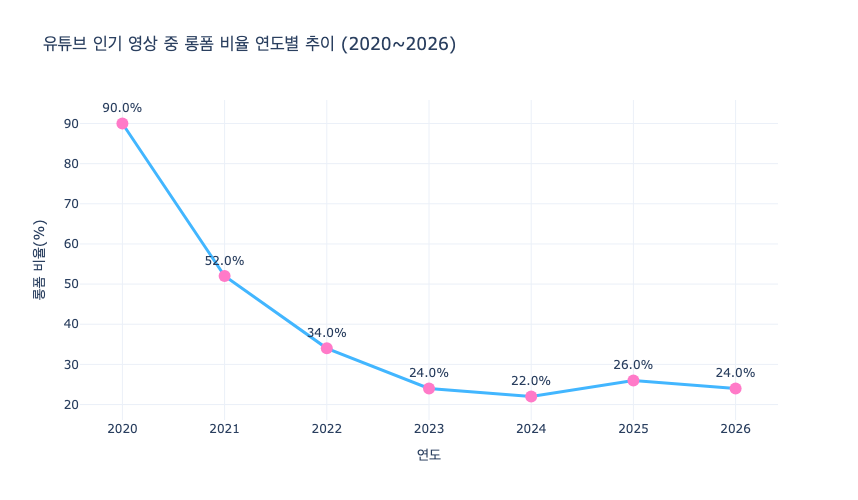

In [9]:
import plotly.graph_objects as go
years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
longform_ratios = []

for year in years:
    year_df = df_trend[df_trend['period'] == year]
    ratio = round(year_df[year_df['format_type'] == 'longform'].shape[0] / len(year_df) * 100, 1)
    longform_ratios.append(ratio)
    print(f'{year}년 롱폼 비율: {ratio}%')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=years,
    y=longform_ratios,
    mode='lines+markers+text',
    text=[f'{r}%' for r in longform_ratios],
    textposition='top center',
    line=dict(color='#42B6FF', width=3),
    marker=dict(color='#FF7AC8', size=12)
))
fig.update_layout(
    title='유튜브 인기 영상 중 롱폼 비율 연도별 추이 (2020~2026)',
    yaxis_title='롱폼 비율(%)',
    xaxis_title='연도',
    template='plotly_white',
    height=500
)
fig.show()

2020년 롱폼 평균 좋아요율: 1.6161%
2021년 롱폼 평균 좋아요율: 0.9235%
2022년 롱폼 평균 좋아요율: 0.8033%
2023년 롱폼 평균 좋아요율: 0.6503%
2024년 롱폼 평균 좋아요율: 0.9032%
2025년 롱폼 평균 좋아요율: 1.3105%
2026년 롱폼 평균 좋아요율: 2.6019%


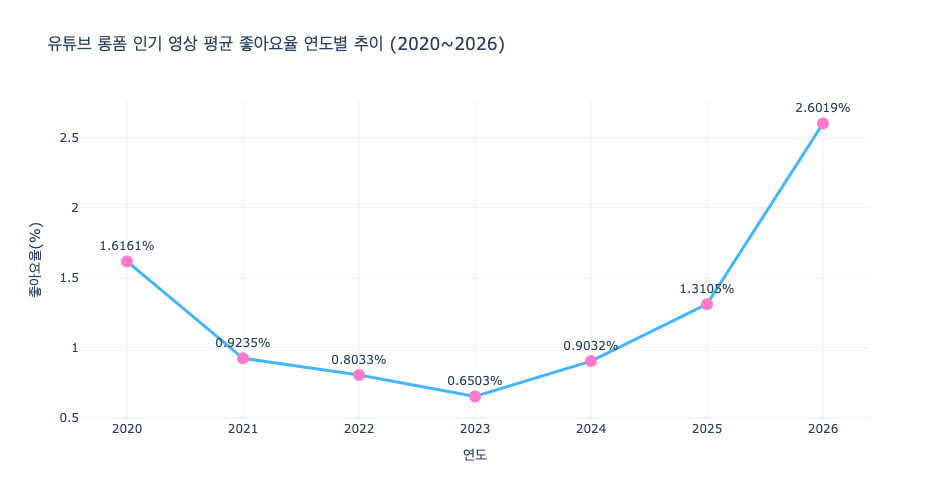

In [10]:
# 롱폼 영상만 필터링
longform_only = df_trend[df_trend['format_type'] == 'longform'].copy()

# 좋아요율 계산
longform_only['like_rate'] = longform_only['like_count'] / longform_only['view_count'].replace(0, 1) * 100

# 연도별 평균 좋아요율
yearly_like_rate = []
for year in years:
    year_df = longform_only[longform_only['period'] == year]
    if len(year_df) > 0:
        rate = round(year_df['like_rate'].mean(), 4)
    else:
        rate = 0
    yearly_like_rate.append(rate)
    print(f'{year}년 롱폼 평균 좋아요율: {rate}%')

# 시각화
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=years,
    y=yearly_like_rate,
    mode='lines+markers+text',
    text=[f'{r}%' for r in yearly_like_rate],
    textposition='top center',
    line=dict(color='#42B6FF', width=3),
    marker=dict(color='#FF7AC8', size=12)
))
fig2.update_layout(
    title='유튜브 롱폼 인기 영상 평균 좋아요율 연도별 추이 (2020~2026)',
    yaxis_title='좋아요율(%)',
    xaxis_title='연도',
    template='plotly_white',
    height=500
)
fig2.show()

In [12]:
df_trend.to_csv('/Users/jeong-eunseo/Data/teamProject/PM_dataproject/YOUTUBE_API/collectors/trend/shortform_trend.csv', index=False, encoding='utf-8-sig')
print('CSV 저장 완료')

CSV 저장 완료
